## 📊 Data Sources and Usage in Model

1. **GDP per capita, PPP (constant 2021 international $)**  
   **Source**: World Bank  
   **Description**:  
   International Comparison Program, World Bank | World Development Indicators database, World Bank | Eurostat-OECD PPP Programme.  
   **Used in model**: *ln-transformed*

2. **International tourism, number of arrivals**  
   **Source**: World Bank  
   **Description**:  
   World Tourism Organization, *Yearbook of Tourism Statistics*, *Compendium of Tourism Statistics*, and data files.  
   **Used in model**: *ln-transformed (dependent variable)*

3. **Political Stability and Absence of Violence/Terrorism: Estimate**  
   **Source**: World Bank  
   **Description**:  
   Measures perceptions of the likelihood of political instability and/or politically-motivated violence, including terrorism.  
   The estimate represents the country's score on the aggregate indicator, expressed in standard normal units, ranging approximately from -2.5 (weak) to 2.5 (strong).  
   **Used in model**: *Raw form (not transformed)*

4. **Official exchange rate (LCU per US$, period average)**  
   **Source**: World Bank  
   **Description**:  
   International Monetary Fund, *International Financial Statistics*.  
   **Used in model**: *ln-transformed*

5. **UNESCO World Heritage Sites (total number)**  
   **Source**: UNESCO World Heritage Centre  
   **URL**: [https://whc.unesco.org/en/list/](https://whc.unesco.org/en/list/)  
   **Used in model**: *Not included directly*

6. **Air transport, passengers carried**  
   **Source**: World Bank (assumed)  
   **Description**: Number of passengers carried by air transport.  
   **Used in model**: *ln-transformed*

7. **`politunesco` (interaction term)**  
   **Description**: Interaction between Political Stability and number of UNESCO World Heritage Sites.  
   **Used in model**: *As a constructed interaction term*

8. **Rule of Law**
  **Source**: Worldwide Governance Indicators (World Bank)
  **Description**: This indicator reflects perceptions of the extent to which agents have confidence in and abide by the rules of society, including the quality of contract enforcement, property rights, the police, and the courts, as well as the likelihood of crime and violence.
  **Used in model**: Raw score or standardized score (specify if applicable)


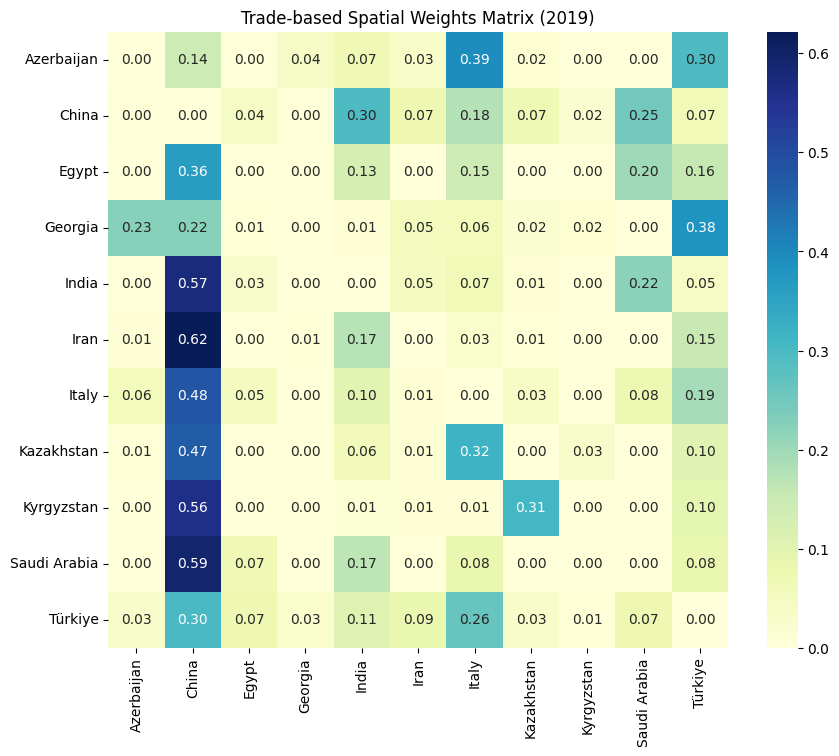

In [3]:
import pandas as pd
import numpy as np

# Load raw data
df = pd.read_excel("/content/trade_2002_2019.xlsx")

# Keep only exports (from the reporter to the partner perspective)
df = df[df['flowCode'].isin(['X', 'M'])].copy()

# Rename columns for consistency
df.rename(columns={
    'refYear': 'year',
    'reporterDesc': 'from',
    'partnerDesc': 'to',
    'primaryValue': 'value'
}, inplace=True)

# Filter only the countries included in the analysis
selected_countries = [
    "Azerbaijan",
    "China",
    "Egypt",
    "Georgia",
    "India",
    "Iran",
    "Italy",
    "Kazakhstan",
    "Kyrgyzstan",
    "Saudi Arabia",
    "Türkiye"
]
df = df[df['from'].isin(selected_countries) & df['to'].isin(selected_countries)]

# List of all countries
countries = sorted(set(df['from']).union(df['to']))
country_to_idx = {country: i for i, country in enumerate(countries)}
n = len(countries)

# Create a dictionary of weight matrices W for each year
W_dict = {}

for year in sorted(df['year'].unique()):
    df_y = df[df['year'] == year]

    # Raw weight matrix
    W = np.zeros((n, n))

    for _, row in df_y.iterrows():
        i = country_to_idx[row['from']]
        j = country_to_idx[row['to']]
        W[i, j] += row['value']

    # Set self-trade to zero
    np.fill_diagonal(W, 0)

    # Row-normalization
    row_sums = W.sum(axis=1).reshape(-1, 1)
    W_normalized = np.divide(W, row_sums, out=np.zeros_like(W), where=row_sums != 0)

    W_dict[year] = W_normalized

# To visualize W for a specific year, e.g., 2019:
import seaborn as sns
import matplotlib.pyplot as plt

W_sample = W_dict[2019]
plt.figure(figsize=(10, 8))
sns.heatmap(W_sample, xticklabels=countries, yticklabels=countries, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Trade-based Spatial Weights Matrix (2019)")
plt.show()



### Construction of Trade-Based Spatial Weight Matrices

We used bilateral trade data from the World Trade Organization (2002–2019) to construct yearly trade-based spatial weight matrices \(W\). The process is as follows:

1. **Select trade flows:** We only consider exports (`X`) and imports (`M`) from the reporter country to the partner country.
2. **Filter countries:** Only the 11 countries included in our analysis are retained.
3. **Construct raw weight matrix:** For each year, a square matrix \(W\) of size \(N \times N\) is created, where \(N\) is the number of countries. Each element \(W[i,j]\) represents the total trade from country \(i\) to country \(j\) in USD.
4. **Remove self-trade:** Diagonal elements \(W[i,i]\) are set to zero.
5. **Row-normalization:** Each row is divided by its sum so that the row sums equal 1. This ensures the matrix represents the **proportion of country \(i\)'s total trade directed to other countries**.

> **Example:** If China exports 100 million USD to Azerbaijan and 200 million USD to India in a given year, the corresponding row in \(W\) after normalization will be `[0, 0.33, 0.67, …]`.

6. **Usage:** These normalized matrices \(W\) are then used to compute spatial lags of the dependent variable (`Wy`) and explanatory variables (`WX`) in the Spatial Durbin Model (SDM).



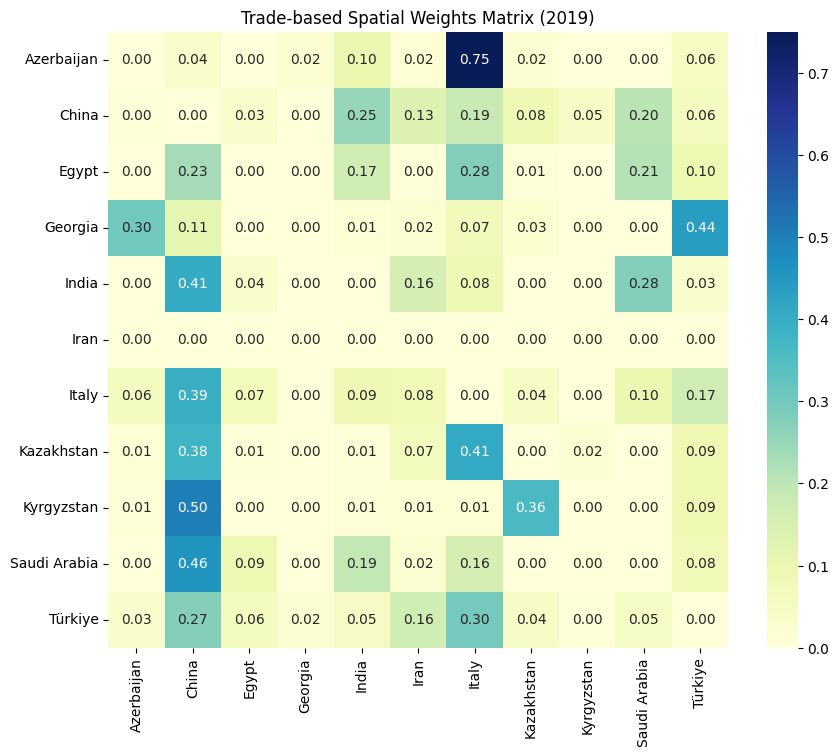

In [2]:
W_sample = W_dict[2008]
plt.figure(figsize=(10, 8))
sns.heatmap(W_sample, xticklabels=countries, yticklabels=countries, cmap="YlGnBu", annot=True, fmt=".2f")
plt.title("Trade-based Spatial Weights Matrix (2019)")
plt.show()

In [4]:
import pandas as pd

# Read the Excel file
df_sorted = pd.read_excel('FINAL_WIDE_W_14020317.xlsx')

# Display the first few rows to check if it was read correctly
df_sorted

,country,year,GDP,inbound,Political Stability,exchange rate,Airtran,politunesco,Rule of Law: Estimate,unesco
0,Azerbaijan,2002,8.79,13.63,-1.19,-0.03,13.26,-5.93,-0.96,5.0
1,Azerbaijan,2003,8.88,13.85,-0.95,-0.02,13.44,-4.74,-0.88,5.0
2,Azerbaijan,2004,8.96,14.06,-1.06,-0.02,13.82,-5.30,-0.90,5.0
3,Azerbaijan,2005,9.20,13.98,-1.12,-0.06,13.94,-5.62,-0.79,5.0
4,Azerbaijan,2006,9.49,13.99,-1.09,-0.11,14.04,-5.46,-0.89,5.0
...,...,...,...,...,...,...,...,...,...,...
193,Türkiye,2015,10.16,17.53,-1.50,1.00,18.39,-11.96,-0.23,8.0
194,Türkiye,2016,10.18,17.25,-2.01,1.11,18.42,-16.06,-0.34,8.0
195,Türkiye,2017,10.23,17.45,-1.79,1.29,18.50,-14.29,-0.32,8.0
196,Türkiye,2018,10.25,17.65,-1.32,1.57,18.57,-10.52,-0.39,8.0


In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Standardize the 'politunesco' variable
scaler = StandardScaler()
df_sorted['ps_x_unesco_scaled'] = scaler.fit_transform(df_sorted[['politunesco']])

# Min-max normalization for UNESCO sites to range [0, 1]
scaler = MinMaxScaler()
df_sorted['unesco_scaled'] = scaler.fit_transform(df_sorted[['unesco']])

# Standardize 'Rule of Law: Estimate'
df_sorted['rulelaw_scaled'] = (
    df_sorted['Rule of Law: Estimate'] - df_sorted['Rule of Law: Estimate'].mean()
) / df_sorted['Rule of Law: Estimate'].std()

# Interaction term: normalized UNESCO sites × standardized Rule of Law
df_sorted['unesco_x_rulelaw'] = df_sorted['unesco_scaled'] * df_sorted['rulelaw_scaled']

# Display the resulting dataframe
df_sorted


,country,year,GDP,inbound,Political Stability,exchange rate,Airtran,politunesco,Rule of Law: Estimate,unesco,ps_x_unesco_scaled,unesco_scaled,rulelaw_scaled,unesco_x_rulelaw
0,Azerbaijan,2002,8.79,13.63,-1.19,-0.03,13.26,-5.93,-0.96,5.0,0.191522,0.035088,-1.100855,-0.038626
1,Azerbaijan,2003,8.88,13.85,-0.95,-0.02,13.44,-4.74,-0.88,5.0,0.252385,0.035088,-0.944155,-0.033128
2,Azerbaijan,2004,8.96,14.06,-1.06,-0.02,13.82,-5.30,-0.90,5.0,0.223744,0.035088,-0.983330,-0.034503
3,Azerbaijan,2005,9.20,13.98,-1.12,-0.06,13.94,-5.62,-0.79,5.0,0.207377,0.035088,-0.767868,-0.026943
4,Azerbaijan,2006,9.49,13.99,-1.09,-0.11,14.04,-5.46,-0.89,5.0,0.215560,0.035088,-0.963743,-0.033816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,Türkiye,2015,10.16,17.53,-1.50,1.00,18.39,-11.96,-0.23,8.0,-0.116882,0.087719,0.329030,0.028862
194,Türkiye,2016,10.18,17.25,-2.01,1.11,18.42,-16.06,-0.34,8.0,-0.326576,0.087719,0.113568,0.009962
195,Türkiye,2017,10.23,17.45,-1.79,1.29,18.50,-14.29,-0.32,8.0,-0.236049,0.087719,0.152743,0.013398
196,Türkiye,2018,10.25,17.65,-1.32,1.57,18.57,-10.52,-0.39,8.0,-0.043233,0.087719,0.015630,0.001371


SDM- Trade Weight Dynamics

 Progress                    Draws   Divergences   Step size   Grad evals   Sampling Speed   Elapsed   Remaining  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.059       63           74.19 draws/s    0:00:26   0:00:00    
  ━━━━━━━━━━━━━━━━━━━━━━━━━   2000    0             0.055       127          37.35 draws/s    0:00:53   0:00:00

array([[<Axes: title={'center': 'rho'}>,
        <Axes: title={'center': 'gamma\n0'}>,
        <Axes: title={'center': 'gamma\n1'}>],
       [<Axes: title={'center': 'gamma\n2'}>,
        <Axes: title={'center': 'gamma\n3'}>, <Axes: >]], dtype=object)

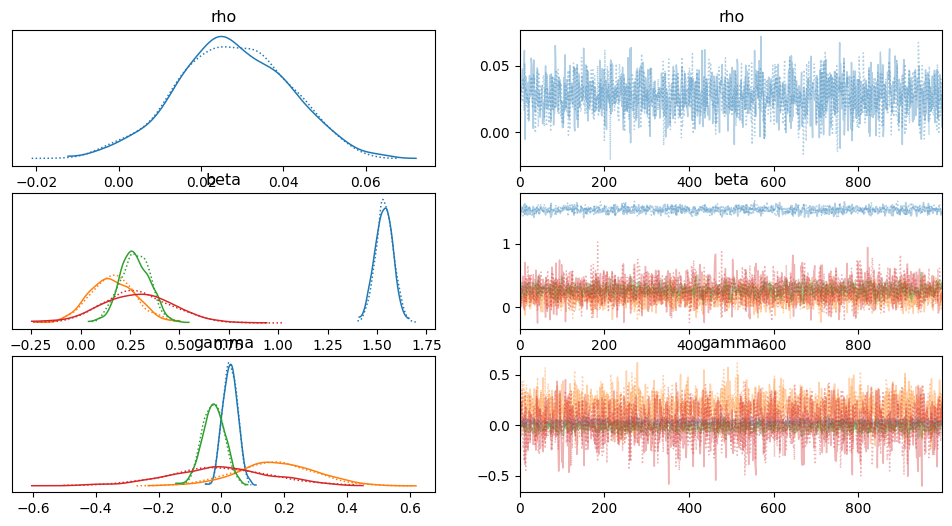

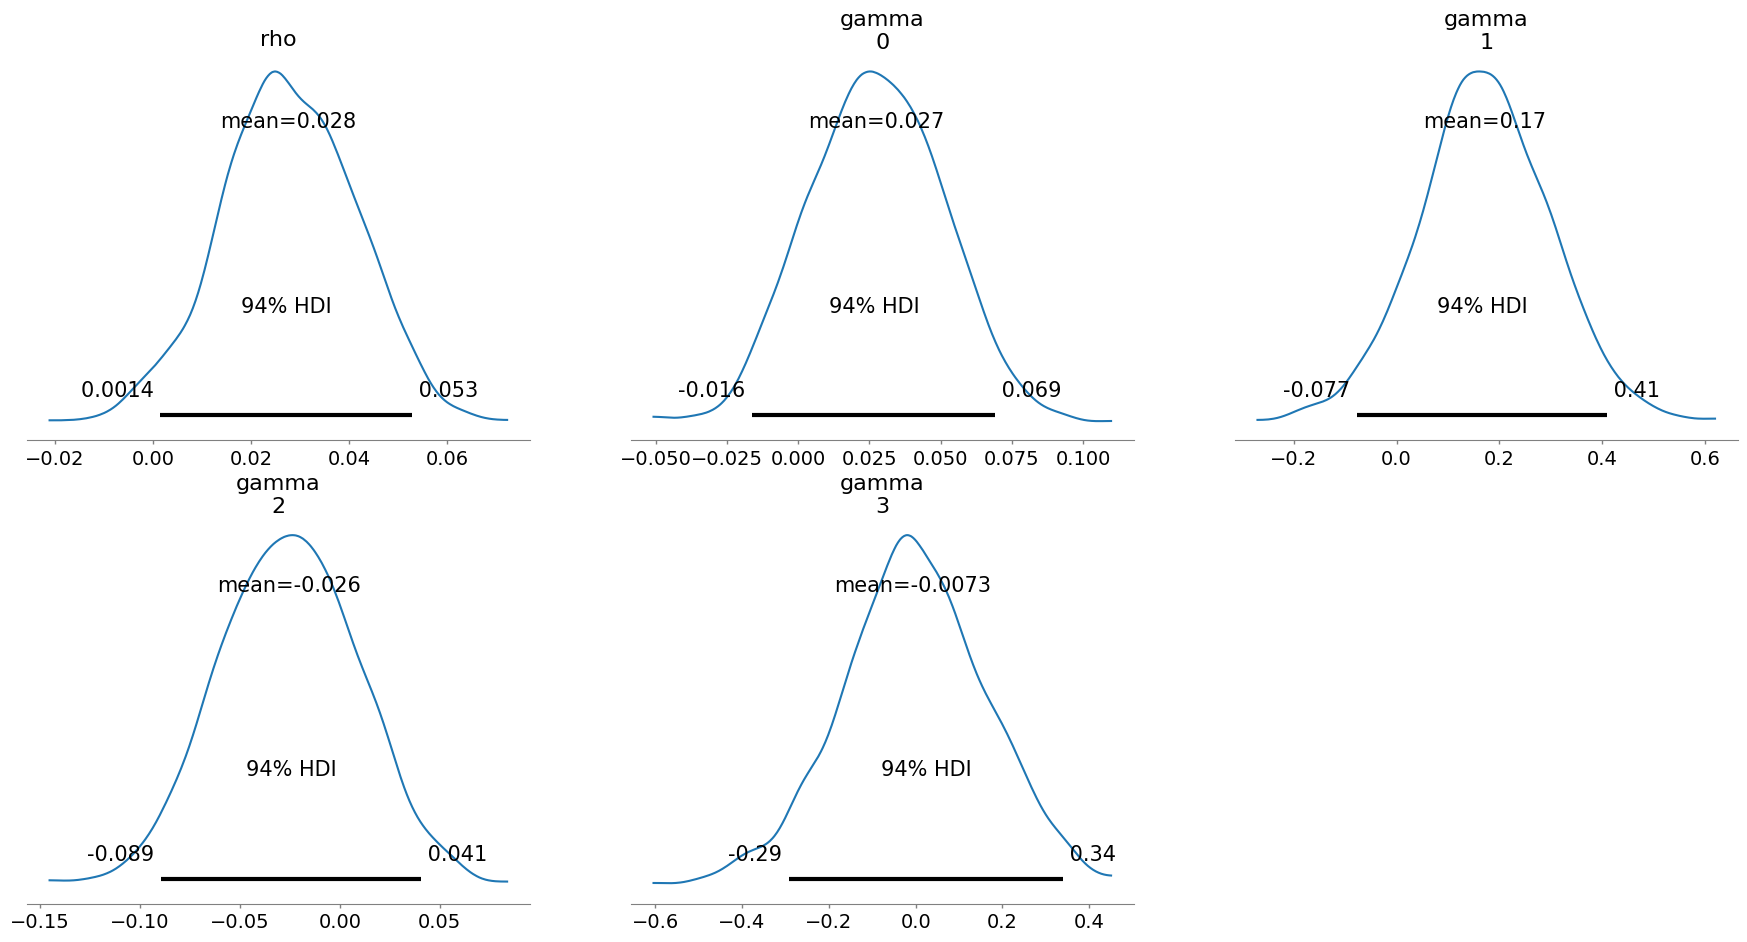

In [7]:
import pymc as pm
import arviz as az
import pandas as pd
import numpy as np

# Prepare X and y
X = df_sorted[['GDP', 'Political Stability', 'exchange rate', "Rule of Law: Estimate"]].values
K = X.shape[1]            # Number of independent variables
N = df_sorted.shape[0]    # Total number of rows (observations)
y = df_sorted['inbound'].values

# Assumption: df_sorted includes country, year, inbound, and explanatory variables (like GDP, Political Stability)
# X: NumPy array (N*T × K)
# y: NumPy array (inbound tourism, N*T × 1)
# W_dict: dictionary of trade-based weight matrices for each year

# Step 1: Data preparation
countries = sorted(df_sorted['country'].unique())
country_to_idx = {c: i for i, c in enumerate(countries)}
years = sorted(df_sorted['year'].unique())
year_to_idx = {y: i for i, y in enumerate(years)}
N = len(countries)  # 12 countries
T = len(years)      # 17 years
K = X.shape[1]      # Number of explanatory variables

# Construct y_neighbors (Wy) and WX
y_neighbors = []
WX = np.zeros((N * T, K))

for idx, row in df_sorted.iterrows():
    year = row['year']
    country = row['country']
    c_idx = country_to_idx[country]
    y_idx = year_to_idx[year]
    obs_idx = y_idx * N + c_idx

    # Weight matrix for the year
    W = W_dict[year]

    # y values for that year
    y_t = df_sorted[df_sorted['year'] == year].set_index('country').loc[countries]['inbound'].values

    # Compute Wy
    wy = np.dot(W[c_idx], y_t)
    y_neighbors.append(wy)

    # Compute WX (using X array)
    X_t = X[y_idx * N:(y_idx + 1) * N]  # X for current year
    WX[obs_idx] = np.dot(W[c_idx], X_t)

y_neighbors = np.array(y_neighbors)

# Step 2: SDM model
with pm.Model() as sdm_model:
    beta = pm.Normal("beta", mu=0, sigma=10, shape=K)
    gamma = pm.Normal("gamma", mu=0, sigma=10, shape=K)  # coefficients for WX
    alpha = pm.Normal("alpha", mu=0, sigma=1, shape=N)
    rho = pm.Normal("rho", mu=0, sigma=1)
    sigma = pm.HalfCauchy("sigma", beta=2)

    country_idx = pd.Categorical(df_sorted['country']).codes
    mu = pm.math.dot(X, beta) + pm.math.dot(WX, gamma) + alpha[country_idx] + rho * y_neighbors

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)

# Step 3: Output
summary = az.summary(trace, var_names=["rho", "beta", "gamma", "sigma", "alpha"])
summary
az.plot_trace(trace, var_names=["rho", "beta", "gamma"])
az.plot_posterior(trace, var_names=["rho", "gamma"])


In [8]:
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
rho,0.028,0.014,0.001,0.053,0.000,0.000,1910.0,1502.0,1.00
beta[0],1.536,0.045,1.449,1.617,0.001,0.001,1023.0,1240.0,1.00
beta[1],0.162,0.117,-0.075,0.367,0.003,0.002,1953.0,1627.0,1.00
beta[2],0.276,0.075,0.132,0.411,0.002,0.002,1174.0,1377.0,1.00
beta[3],0.286,0.180,-0.051,0.620,0.004,0.004,1611.0,1401.0,1.00
gamma[0],0.027,0.023,-0.016,0.069,0.001,0.001,2189.0,1524.0,1.00
gamma[1],0.171,0.129,-0.077,0.409,0.003,0.003,2077.0,1584.0,1.00
gamma[2],-0.026,0.035,-0.089,0.041,0.001,0.001,1553.0,1308.0,1.00
gamma[3],-0.007,0.168,-0.292,0.341,0.004,0.004,1602.0,1245.0,1.00
sigma,0.427,0.023,0.384,0.469,0.000,0.000,2324.0,1439.0,1.00


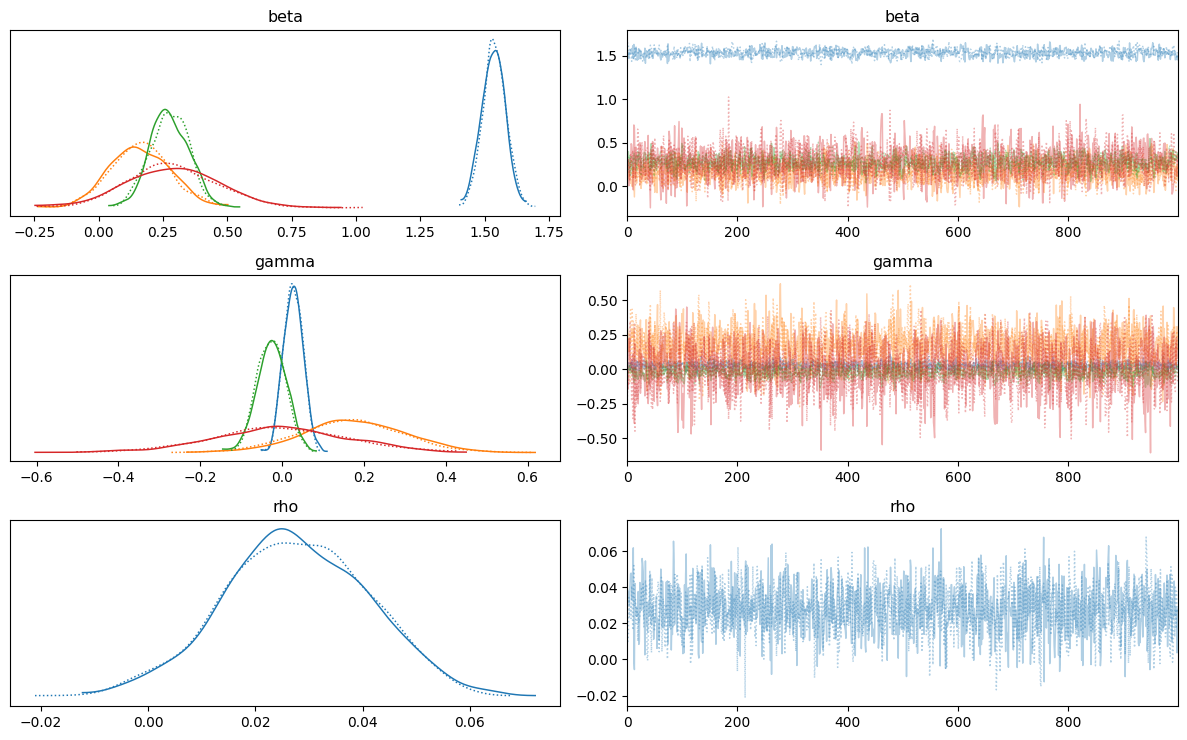

In [10]:
import arviz as az
import matplotlib.pyplot as plt

# Model parameter names for more readable labels
param_labels = {
    'beta[0]': 'GDP',
    'beta[1]': 'Political Stability',
    'beta[2]': 'Exchange Rate',
    'beta[3]': 'Air Transport',
    'beta[4]': 'Political Stability × UNESCO',
    'gamma[0]': 'Dynamic Trade-Weighted GDP',
    'gamma[1]': 'Dynamic Trade-Weighted Political Stability',
    'gamma[2]': 'Dynamic Trade-Weighted Exchange Rate',
    'gamma[3]': 'Dynamic Trade-Weighted Air Transport',
    'gamma[4]': 'Dynamic Trade-Weighted Political Stability × UNESCO',
    'rho': 'Spatial Autocorrelation (rho)',
    'sigma': 'Sigma'
}

# Function to customize x-axis labels in trace plots
def custom_traceplot(trace, var_names):
    az.plot_trace(trace, var_names=var_names, figsize=(12, len(var_names)*2.5))

    axes = plt.gcf().axes
    for ax in axes:
        label = ax.get_xlabel()
        if label in param_labels:
            ax.set_xlabel(param_labels[label], fontsize=12, color='darkblue')
    plt.tight_layout()
    plt.show()

# Usage
custom_traceplot(trace, var_names=['beta', 'gamma', 'rho'])


In [12]:
import numpy as np

# Posterior means from the trace
beta_mean = trace.posterior['beta'].mean(dim=['chain', 'draw']).values
gamma_mean = trace.posterior['gamma'].mean(dim=['chain', 'draw']).values
rho_mean = trace.posterior['rho'].mean(dim=['chain', 'draw']).values
alpha_mean = trace.posterior['alpha'].mean(dim=['chain', 'draw']).values

# Base prediction
y_base = X @ beta_mean + WX @ gamma_mean + alpha_mean[pd.Categorical(df_sorted['country']).codes] + rho_mean * y_neighbors

# Change one variable (e.g., GDP) by one standard deviation
X_sens = X.copy()
X_sens[:, 0] += X[:, 0].std()  # assuming column 0 = GDP

y_sens = X_sens @ beta_mean + WX @ gamma_mean + alpha_mean[pd.Categorical(df_sorted['country']).codes] + rho_mean * y_neighbors

# Effect of the GDP change
effect_gdp = y_sens - y_base
print("Average effect of 1 std increase in GDP:", np.mean(effect_gdp))



Average effect of 1 std increase in GDP: 1.1933503336942939


/tmp/ipython-input-2451203360.py:10: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  alpha_hdi = az.hdi(alpha_samples.T, hdi_prob=0.94)  # shape: (N countries, 2)


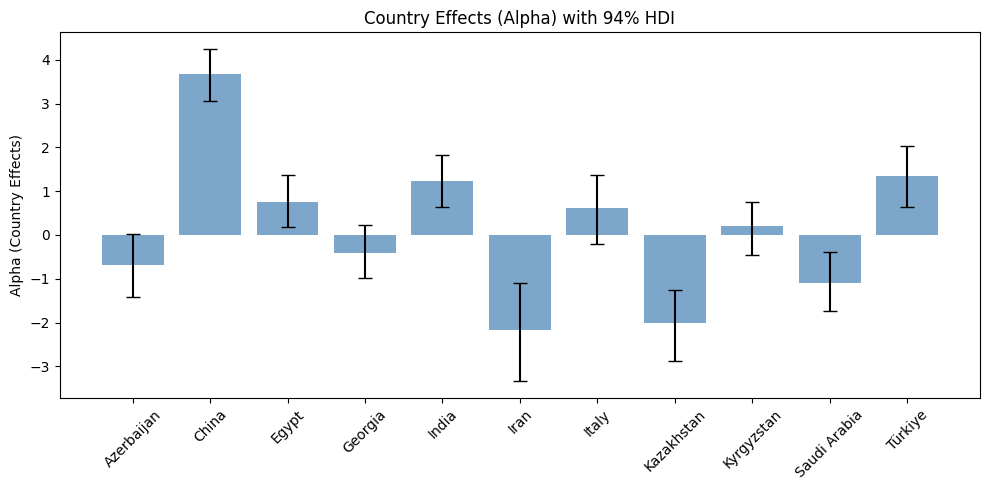

In [13]:
import matplotlib.pyplot as plt
import arviz as az
import numpy as np

# Extract country effects (alpha) from the trace
alpha_samples = trace.posterior["alpha"].stack(draws=("chain", "draw")).values  # shape: (N countries, samples)

# Compute mean and HDI
alpha_means = alpha_samples.mean(axis=1)
alpha_hdi = az.hdi(alpha_samples.T, hdi_prob=0.94)  # shape: (N countries, 2)

# Data for plotting
countries_ordered = sorted(country_to_idx.keys())
lower_bounds = alpha_hdi[:, 0]
upper_bounds = alpha_hdi[:, 1]

# Plot bar chart with HDI error bars
fig, ax = plt.subplots(figsize=(10, 5))
errors = [alpha_means - lower_bounds, upper_bounds - alpha_means]
ax.bar(countries_ordered, alpha_means, yerr=errors, capsize=5, color='steelblue', alpha=0.7)

# Aesthetic settings
ax.set_ylabel("Alpha (Country Effects)")
ax.set_title("Country Effects (Alpha) with 94% HDI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)
plt.show()
